In [27]:
##### Calculate and map spatial autocorrelation in target variable

import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from libpysal.weights import Queen
from esda.moran import Moran, Moran_Local
from splot.esda import moran_scatterplot, lisa_cluster

In [28]:
##### Load data

# Get the current working directory
cd = os.path.dirname(os.getcwd())

# Import sub-national data
sub_capital = pd.read_csv(f"{cd}/Data/Clean/Training_data/capital_absolute.csv")
sub_labor = pd.read_csv(f"{cd}/Data/Clean/Training_data/labor_absolute.csv")

sub_capital_rtv = pd.read_csv(f'{cd}/Data/Clean/Training_data/capital_relative_final.csv')
sub_labor_rtv = pd.read_csv(f'{cd}/Data/Clean/Training_data/labor_relative_final.csv')

sub_geo_capital = gpd.read_file(f"{cd}/Data/Clean/Geographies/subnational_capital.shp")
sub_geo_labor = gpd.read_file(f"{cd}/Data/Clean/Geographies/subnational_labor.shp")

# Set file path to figure repo
fd = "/Users/carinamanitius/Library/CloudStorage/OneDrive-UniversityofVermont/Documents/OneDrive/Dissertation/Chapter 1/Figures/morans_I"

In [29]:
### Prep data

# combine capital and labor 
sub_data = pd.concat([sub_capital, sub_labor])
sub_data_rtv = pd.concat([sub_capital_rtv, sub_labor_rtv])
geo = pd.concat([sub_geo_capital, sub_geo_labor])

# combine data and geo
geo_data = geo.merge(sub_data, on='PROJ_ID', how='outer')
geo_data_rtv = geo.merge(sub_data_rtv, on='PROJ_ID', how='outer')
geo_data_full = gpd.GeoDataFrame(pd.concat([geo_data, geo_data_rtv], ignore_index=True), crs=geo_data.crs)

# select columns 
col_to_keep = ['PROJ_ID', 'ISO3',
                'capital_intensity_USD_per_USD', 'capital_intensity_USD_per_tonne', 
                'labor_intensity_jobs_per_million_USD', 'labor_intensity_jobs_per_tonne', 
                'rtv_log_capital_intensity_USD_per_million_USD', 'rtv_log_capital_intensity_USD_per_million_tonne',
                'rtv_log_labor_intensity_jobs_per_million_tonne', 'rtv_log_labor_intensity_jobs_per_million_USD', 
                'geometry'
                ]

geo_data_full = geo_data_full[col_to_keep]

/Users/carinamanitius/Library/Python/3.9/lib/python/site-packages/libpysal/weights/weights.py:224: UserWarning: The weights matrix is not fully connected: 
 There are 70 disconnected components.
 There are 9 islands with ids: 931, 14103, 14104, 14780, 14938, 14941, 14943, 14947, 15010.
  warnings.warn(message)


('WARNING: ', 931, ' is an island (no neighbors)')
('WARNING: ', 14103, ' is an island (no neighbors)')
('WARNING: ', 14104, ' is an island (no neighbors)')
('WARNING: ', 14780, ' is an island (no neighbors)')
('WARNING: ', 14938, ' is an island (no neighbors)')
('WARNING: ', 14941, ' is an island (no neighbors)')
('WARNING: ', 14943, ' is an island (no neighbors)')
('WARNING: ', 14947, ' is an island (no neighbors)')
('WARNING: ', 15010, ' is an island (no neighbors)')
Moran's I: 0.7157
Expected I under null: -0.0000
p-value (simulated): 0.0010
z-score: 234.0195


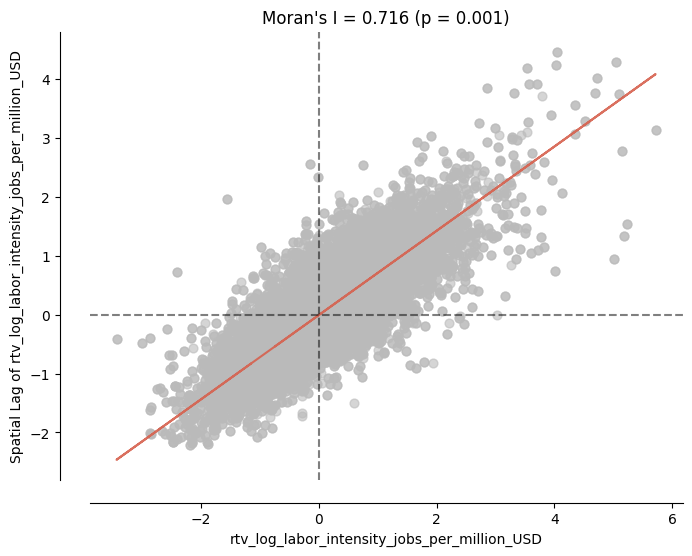

/Users/carinamanitius/Library/Python/3.9/lib/python/site-packages/esda/moran.py:1059: RuntimeWarning: invalid value encountered in divide
  self.z_sim = (self.Is - self.EI_sim) / self.seI_sim


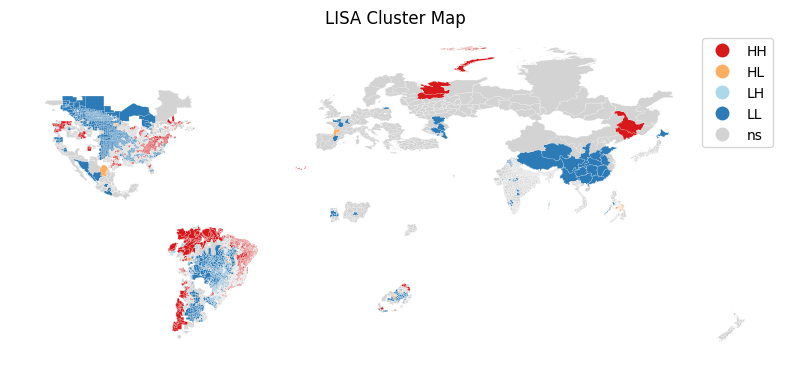

In [30]:
##### Plot Moran's I

# select variable 
# 'capital_intensity_USD_per_USD', 'capital_intensity_USD_per_tonne',
# 'labor_intensity_jobs_per_million_USD', 'labor_intensity_jobs_per_tonne',
# 'rtv_log_capital_intensity_USD_per_million_USD', 'rtv_log_capital_intensity_USD_per_million_tonne',
# 'rtv_log_labor_intensity_jobs_per_million_tonne', 'rtv_log_labor_intensity_jobs_per_million_USD'
col = "rtv_log_labor_intensity_jobs_per_million_USD"

# Drop rows with missing values in the column 
gdf_clean = geo_data_full.dropna(subset=[col]).reset_index(drop=True)

# Build spatial weights
# Queen contiguity is for polygons sharing edges/vertices
w = Queen.from_dataframe(gdf_clean, use_index=False)
w.transform = "r"  # row-standardize weights

# Compute Moran's I
y = gdf_clean[col].values
moran = Moran(y, w)

print(f"Moran's I: {moran.I:.4f}")
print(f"Expected I under null: {moran.EI:.4f}")
print(f"p-value (simulated): {moran.p_sim:.4f}")
print(f"z-score: {moran.z_sim:.4f}")

# Plot Moran scatterplot
fig, ax = moran_scatterplot(moran, aspect_equal=True)
ax.set_xlabel(col)
ax.set_ylabel(f"Spatial Lag of {col}")
ax.set_title(f"Moran's I = {moran.I:.3f} (p = {moran.p_sim:.3f})")
plt.tight_layout()
plt.show()
fig.savefig(f"{fd}/{col}_scatterplot.png", dpi=300, bbox_inches='tight')

# Plot LISA cluster map
# Calculate Local Moran's I
moran_local = Moran_Local(y, w)

# Plot LISA clusters
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
lisa_cluster(moran_local, gdf_clean, p=0.05, ax=ax)
ax.set_title("LISA Cluster Map")
ax.axis("off")
plt.tight_layout()
plt.show()
fig.savefig(f"{fd}/{col}_LISA.png", dpi=300, bbox_inches='tight')